# Demonstration 7th Feb

To demonstrate the relationship between Fourier series and Fourier transform using square wave and a square pulse

In [1]:
import numpy as np 
import sympy as sp
import matplotlib.pyplot as plt
from scipy import integrate 
import basicstools as basic
# I have a module wherein I have stored all the basic computational functions 
# in this case I will need a function for computation of the Fourier coefficients 
# this function is stored in the above module as basicstools.py
# I am not giving you this file because this is a previous exercise

ModuleNotFoundError: No module named 'basicstools'

Let us defin the Periodic Function

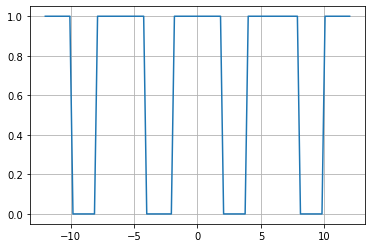

In [ ]:
T0 = 2 
T = 6 
t = sp.symbols("t")
cond1 = (t%T>=0) & (t%T<T0)
cond2 = (t%T>=T0) & (t%T<T-T0)
cond3 = (t%T>=T-T0) & (t%T<T)
x = sp.Piecewise((1, cond1), (0, cond2), (1, cond3))
xnum = sp.lambdify(t, x)
tvec = np.linspace(-2*T, 2*T, 100)
plt.plot(tvec, xnum(tvec))
plt.grid()

We will find the Fourier coefficients of this periodic function

<StemContainer object of 3 artists>

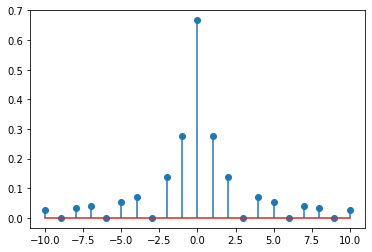

In [ ]:
nvec = np.arange(-10, 11, 1)
Xn = np.zeros_like(nvec, dtype=complex)

for count in range(len(nvec)):
    Xn[count] = basic.fourier_coefficient(xnum, nvec[count], T)
    # you need to write your own function file for computation of the fourier coefficients
    
    
plt.stem(nvec, np.abs(Xn), use_line_collection=True)

Now that the Fourier coefficients of the periodic function is computed, we find the fourier transform of the aperiodic square pulse

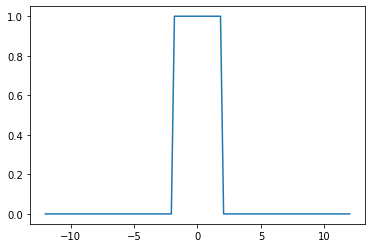

In [ ]:
cond = (t > -T0) & (t < T0) 
xap = sp.Piecewise((1, cond), (0, True))
xap_num = sp.lambdify(t, xap)
plt.plot(tvec, xap_num(tvec))

To calculate the Fourier Transform of this function

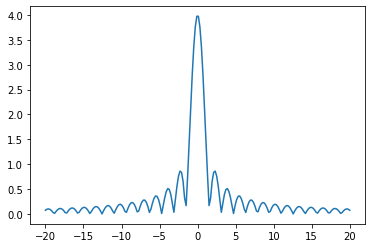

In [ ]:
w = sp.symbols("omega")
cexp = sp.exp(-1.0j*w*t)
Xw = sp.integrate(xap*cexp, (t, -sp.oo, sp.oo))
Xwnum = sp.lambdify(w, Xw)

wvec = np.linspace(-20, 20, 200)
plt.plot(wvec, np.abs(Xwnum(wvec)))

<StemContainer object of 3 artists>

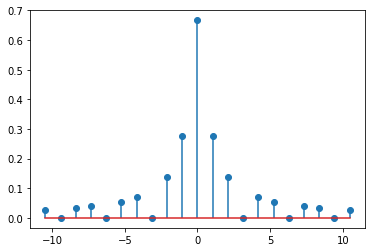

In [ ]:
w0 = 2*np.pi/T
nw = nvec*w0 
plt.stem(nw,  np.abs(Xn), use_line_collection=True)

<StemContainer object of 3 artists>

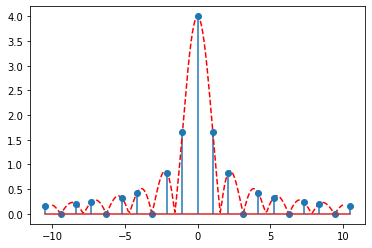

In [ ]:
wvec = np.linspace(-10, 10, 200)
plt.plot(wvec, np.abs(Xwnum(wvec)), 'r--')
plt.stem(nw,  T*np.abs(Xn), use_line_collection=True)

In [ ]:
Xw

Piecewise((-1.0*I*exp(2.0*I*omega)/omega + 1.0*I*exp(-2.0*I*omega)/omega, (omega > -oo) & (omega < oo) & Ne(omega, 0)), (4, True))